# Analyzing Wikipedia Clickstream Data
* [View Solution Notebook](./solution.html)

* [Project Page Link](https://www.codecademy.com/courses/big-data-pyspark/projects/analyzing-wikipedia-pyspark)

In this project, we’re going to continue working with Wikipedia’s open-source datasets. Wikipedia maintains a dataset called “Clickstream” that records clicks between pairs of linked Wikipedia articles. Because not all readers arrive at a Wikipedia article by clicking a link from another, the dataset also includes categories for clicks that originate outside of Wikipedia (e.g., external-search tracks all clicks coming from major search engines).

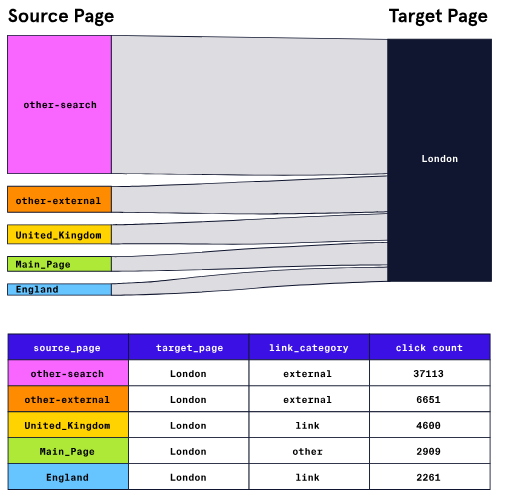

This excerpt tells us about 37,000 people accessed the page for London from an external search engine, and about 4,600 people accessed the page by clicking on a link from the Wikipedia article titled “United Kingdom”. In this project, we’ll clean and analyze a sample of the English language Wikipedia’s Clickstream data from January 2018 using PySpark SQL.

### Import Libraries

In [1]:
from pyspark.sql import SparkSession
import findspark
findspark.init()

## Task Group 1 - Introduction to Clickstream Data

### Task 1
Create a new `SparkSession` and assign it to a variable named `spark`.

In [2]:
# Create a new SparkSession
spark = SparkSession\
    .builder\
    .config('spark.app.name', 'Project 1 ClickStreams')\
    .getOrCreate()

### Task 2

Create an RDD from a list of sample clickstream counts and save it as `clickstream_counts_rdd`.

In [3]:
# Sample clickstream counts
sample_clickstream_counts = [
    ["other-search", "Hanging_Gardens_of_Babylon", "external", 47000],
    ["other-empty", "Hanging_Gardens_of_Babylon", "external", 34600],
    ["Wonders_of_the_World", "Hanging_Gardens_of_Babylon", "link", 14000],
    ["Babylon", "Hanging_Gardens_of_Babylon", "link", 2500]
]

# Create RDD from sample data
clickstream_counts_rdd = spark.sparkContext.parallelize(sample_clickstream_counts)

### Task 3

Using the RDD from the previous step, create a DataFrame named `clickstream_sample_df`

In [4]:
# Create a DataFrame from the RDD of sample clickstream counts
clickstream_sample_df = clickstream_counts_rdd.toDF(['source_page', 'target_page', 'link_category', 'link_count'])

# Display the DataFrame to the notebook
clickstream_sample_df.show(truncate=False)

+--------------------+--------------------------+-------------+----------+
|source_page         |target_page               |link_category|link_count|
+--------------------+--------------------------+-------------+----------+
|other-search        |Hanging_Gardens_of_Babylon|external     |47000     |
|other-empty         |Hanging_Gardens_of_Babylon|external     |34600     |
|Wonders_of_the_World|Hanging_Gardens_of_Babylon|link         |14000     |
|Babylon             |Hanging_Gardens_of_Babylon|link         |2500      |
+--------------------+--------------------------+-------------+----------+



## Task Group 2 - Inspecting Clickstream Data

### Task 4

Read the files in `./cleaned/clickstream/` into a new Spark DataFrame named `clickstream` and display the first few rows of the DataFrame in the notebook

In [5]:
# Read the target directory (`./cleaned/clickstream/`) into a DataFrame (`clickstream`)
clickstream = spark.read\
                    .option('header',True)\
                    .option('delimiter','\t')\
                    .option('inferSchema',True)\
                    .csv('./cleaned/clickstream')

# Display the DataFrame to the notebook
clickstream.show(5)

+-------------------+--------------+-------------+-------------+-----------+
|           referrer|      resource|link_category|language_code|click_count|
+-------------------+--------------+-------------+-------------+-----------+
|   Daniel_Day-Lewis|Phantom_Thread|         link|           en|      43190|
|     other-internal|Phantom_Thread|     external|           en|      21683|
|        other-empty|Phantom_Thread|     external|           en|     169532|
|90th_Academy_Awards|Phantom_Thread|         link|           en|      40449|
|       other-search|Phantom_Thread|     external|           en|     536940|
+-------------------+--------------+-------------+-------------+-----------+
only showing top 5 rows



### Task 5

Print the schema of the DataFrame in the notebook.

In [6]:
# Display the schema of the `clickstream` DataFrame to the notebook
clickstream.printSchema()

root
 |-- referrer: string (nullable = true)
 |-- resource: string (nullable = true)
 |-- link_category: string (nullable = true)
 |-- language_code: string (nullable = true)
 |-- click_count: integer (nullable = true)



### Task 6

Drop the `language_code` column from the DataFrame and display the new schema in the notebook.

In [7]:
# Drop target columns
clickstream = clickstream.drop('language_code')

# Display the first few rows of the DataFrame
clickstream.show(5)
# Display the new schema in the notebook
clickstream.printSchema()

+-------------------+--------------+-------------+-----------+
|           referrer|      resource|link_category|click_count|
+-------------------+--------------+-------------+-----------+
|   Daniel_Day-Lewis|Phantom_Thread|         link|      43190|
|     other-internal|Phantom_Thread|     external|      21683|
|        other-empty|Phantom_Thread|     external|     169532|
|90th_Academy_Awards|Phantom_Thread|         link|      40449|
|       other-search|Phantom_Thread|     external|     536940|
+-------------------+--------------+-------------+-----------+
only showing top 5 rows

root
 |-- referrer: string (nullable = true)
 |-- resource: string (nullable = true)
 |-- link_category: string (nullable = true)
 |-- click_count: integer (nullable = true)



### Task 7

Rename `referrer` and `resource` to `source_page` and `target_page`, respectively,

In [8]:
# Rename `referrer` and `resource` to `source_page` and `target_page`
clickstream = clickstream.withColumnRenamed('referrer', 'source_page')
clickstream = clickstream.withColumnRenamed('resource', 'target_page')
# Display the first few rows of the DataFrame
clickstream.show(5)
# Display the new schema in the notebook
clickstream.printSchema()

+-------------------+--------------+-------------+-----------+
|        source_page|   target_page|link_category|click_count|
+-------------------+--------------+-------------+-----------+
|   Daniel_Day-Lewis|Phantom_Thread|         link|      43190|
|     other-internal|Phantom_Thread|     external|      21683|
|        other-empty|Phantom_Thread|     external|     169532|
|90th_Academy_Awards|Phantom_Thread|         link|      40449|
|       other-search|Phantom_Thread|     external|     536940|
+-------------------+--------------+-------------+-----------+
only showing top 5 rows

root
 |-- source_page: string (nullable = true)
 |-- target_page: string (nullable = true)
 |-- link_category: string (nullable = true)
 |-- click_count: integer (nullable = true)



## Task Group 3 - Querying Clickstream Data

### Task 8

Add the `clickstream` DataFrame as a temporary view named `clickstream` to make the data queryable with `sparkSession.sql()`

In [9]:
# Create a temporary view in the metadata for this `SparkSession` 
clickstream.createOrReplaceTempView('clickstream')

### Task 9

Filter the dataset to entries with `Hanging_Gardens_of_Babylon` as the `target_page` and order the result by `click_count` using PySpark DataFrame methods.

In [10]:
# Filter and sort the DataFrame using PySpark DataFrame methods
hanging_clicks = clickstream.filter(clickstream.target_page == 'Hanging_Gardens_of_Babylon')\
                            .orderBy('click_count', ascending=False)\
                            .show(truncate=False)

+----------------------------------+--------------------------+-------------+-----------+
|source_page                       |target_page               |link_category|click_count|
+----------------------------------+--------------------------+-------------+-----------+
|other-search                      |Hanging_Gardens_of_Babylon|external     |47088      |
|other-empty                       |Hanging_Gardens_of_Babylon|external     |34619      |
|Wonders_of_the_World              |Hanging_Gardens_of_Babylon|link         |14668      |
|Seven_Wonders_of_the_Ancient_World|Hanging_Gardens_of_Babylon|link         |12296      |
+----------------------------------+--------------------------+-------------+-----------+



### Task 10

Perform the same analysis as the previous exercise using a SQL query. 

In [11]:
# Filter and sort the DataFrame using SQL
query = """ 
select
    *
from
    clickstream
where
    target_page = 'Hanging_Gardens_of_Babylon'
order by 
    click_count desc
"""
spark.sql(query).show(truncate=False)

+----------------------------------+--------------------------+-------------+-----------+
|source_page                       |target_page               |link_category|click_count|
+----------------------------------+--------------------------+-------------+-----------+
|other-search                      |Hanging_Gardens_of_Babylon|external     |47088      |
|other-empty                       |Hanging_Gardens_of_Babylon|external     |34619      |
|Wonders_of_the_World              |Hanging_Gardens_of_Babylon|link         |14668      |
|Seven_Wonders_of_the_Ancient_World|Hanging_Gardens_of_Babylon|link         |12296      |
+----------------------------------+--------------------------+-------------+-----------+



### Task 11

Calculate the sum of `click_count` grouped by `link_category` using PySpark DataFrame methods.

In [12]:
# Aggregate the DataFrame using PySpark DataFrame Methods 
clickstream.groupBy('link_category')\
            .sum()\
            .show(truncate=False)

+-------------+----------------+
|link_category|sum(click_count)|
+-------------+----------------+
|link         |97805811        |
|other        |9338172         |
|external     |3248677856      |
+-------------+----------------+



### Task 12

Perform the same analysis as the previous exercise using a SQL query.

In [14]:
# Aggregate the DataFrame using SQL
query = """ 
select
    link_category
    ,sum(click_count)
from
    clickstream
group by 
    link_category
order by
    2 desc
"""
spark.sql(query).show(truncate=False)

+-------------+----------------+
|link_category|sum(click_count)|
+-------------+----------------+
|external     |3248677856      |
|link         |97805811        |
|other        |9338172         |
+-------------+----------------+



## Task Group 4 - Saving Results to Disk

### Task 13

Let's create a new DataFrame named `internal_clickstream` that only contains article pairs where `link_category` is `link`. Use `filter()` to select rows to a specific condition and `select()` to choose which columns to return from the query.

In [15]:
# Create a new DataFrame named `internal_clickstream`
internal_clickstream = clickstream.filter(clickstream.link_category == 'link')\
                                    .select(['source_page','target_page','click_count'])

# Display the first few rows of the DataFrame in the notebook
internal_clickstream.show(5, truncate=False)

+-------------------+----------------------+-----------+
|source_page        |target_page           |click_count|
+-------------------+----------------------+-----------+
|Daniel_Day-Lewis   |Phantom_Thread        |43190      |
|90th_Academy_Awards|Phantom_Thread        |40449      |
|Shinee             |Kim_Jong-hyun_(singer)|24433      |
|Agnyaathavaasi     |Anu_Emmanuel          |15020      |
|Naa_Peru_Surya     |Anu_Emmanuel          |12361      |
+-------------------+----------------------+-----------+
only showing top 5 rows



### Task 14

Using `DataFrame.write.csv()`, save the `internal_clickstream` DataFrame as CSV files in a directory called `./results/article_to_article_csv/`.

In [16]:
# Save the `internal_clickstream` DataFrame to a series of CSV files
internal_clickstream.write.csv('./results/article_to_article_csv/', mode = 'overwrite')

### Task 15

Using `DataFrame.write.parquet()`, save the `internal_clickstream` DataFrame as parquet files in a directory called `./results/article_to_article_pq/`.

In [21]:
# Save the `internal_clickstream` DataFrame to a series of parquet files
internal_clickstream.write.parquet('./results/article_to_article_pq/', mode = 'overwrite')

### Task 16

Close the `SparkSession` and underlying `SparkContext`. What happens if you we call `clickstream.show()` after closing the `SparkSession`?

In [23]:
# Stop the notebook's `SparkSession` and `SparkContext`
spark.stop()

In [24]:
# The SparkSession and sparkContext are stopped; the following line will throw an error:
clickstream.show()

Py4JJavaError: An error occurred while calling o77.showString.
: java.lang.IllegalStateException: Cannot call methods on a stopped SparkContext.
This stopped SparkContext was created at:

org.apache.spark.api.java.JavaSparkContext.<init>(JavaSparkContext.scala:58)
sun.reflect.NativeConstructorAccessorImpl.newInstance0(Native Method)
sun.reflect.NativeConstructorAccessorImpl.newInstance(Unknown Source)
sun.reflect.DelegatingConstructorAccessorImpl.newInstance(Unknown Source)
java.lang.reflect.Constructor.newInstance(Unknown Source)
py4j.reflection.MethodInvoker.invoke(MethodInvoker.java:247)
py4j.reflection.ReflectionEngine.invoke(ReflectionEngine.java:374)
py4j.Gateway.invoke(Gateway.java:238)
py4j.commands.ConstructorCommand.invokeConstructor(ConstructorCommand.java:80)
py4j.commands.ConstructorCommand.execute(ConstructorCommand.java:69)
py4j.ClientServerConnection.waitForCommands(ClientServerConnection.java:182)
py4j.ClientServerConnection.run(ClientServerConnection.java:106)
java.la